In [19]:
# Load required libraries 
import numpy as np
from matplotlib import pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, Exponentiation, ExpSineSquared, Matern
import seaborn as sns

In [26]:
# Define the GPR function
def GPR_Model(X, y, training_indices):
    """
    Fits a Gaussian Process Regressor on data and returns the mean and standard deviation of predictions
    :param X: 1D vector containing the x values of observed data (e.g. months)
    :param y: 1D vector containing the y values of observed data (e.g. steam flow)
    :param training_indices: The indices of observations to train on.
    :param well_number: The number of the well being modeled (for labeling purposes)
    :param color: The color for the plot of this well's data
    :return: mean_prediction, std_prediction
    """
    X_train, y_train = X[training_indices], y[training_indices]

    kernel = Exponentiation(1**2*RationalQuadratic(length_scale_bounds=(1e-1,5)), exponent=2)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-10)

    gaussian_process.fit(X_train, y_train)

    mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

    return mean_prediction, std_prediction

C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter kernel__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter kernel__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "


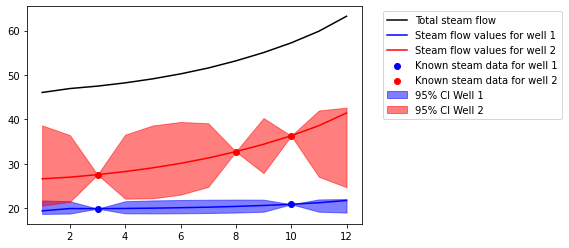

In [27]:
Months = np.linspace(start=1, stop=12, num=12).reshape(-1, 1)

# Well 1 data
y_well1 = np.array([19.42, 19.94, 19.92, 19.96, 20.03, 20.13, 20.25, 20.42, 20.63, 20.9, 21.25, 21.76])
training_indices_well1 = np.array([2, 9]) 

# Well 2 data
y_well2 = np.array([26.64, 27, 27.57, 28.26, 29.1, 30.11, 31.31, 32.75, 34.4, 36.32, 38.59, 41.45])
training_indices_well2 = np.array([2, 7, 9])

MP_1, SP_1 = GPR_Model(Months, y_well1, training_indices_well1)
MP_2, SP_2 = GPR_Model(Months, y_well2, training_indices_well2)

total_steam = y_well1 + y_well2

plt.plot(Months, total_steam, color="black", label="Total steam flow")
plt.scatter(Months[training_indices_well1], y_well1[training_indices_well1], label="Known steam data for well 1", color="blue")
plt.scatter(Months[training_indices_well2], y_well2[training_indices_well2], label="Known steam data for well 2", color="red")

# Plot predictions for well 1
plt.plot(Months, y_well1, label="Steam flow values for well 1", color='blue')
plt.fill_between(
    Months.ravel(),
    MP_1 - 1.96 * SP_1,
    MP_1 + 1.96 * SP_1,
    alpha=0.5,
    color='blue',
    label="95% CI Well 1"
)

# Plot predictions for well 2
plt.plot(Months, y_well2, label="Steam flow values for well 2", color='red')
plt.fill_between(
    Months.ravel(),
    MP_2 - 1.96 * SP_2,
    MP_2 + 1.96 * SP_2,
    alpha=0.5,
    color='red',
    label="95% CI Well 2"
)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')